# Hybrid Knowledge Graph Course Recommendation
**Author:** Mahmuda Akter Lubna

> **Every new Colab session: run Cell 0 first, then run all cells top to bottom.**

In [ ]:
# CELL 0 - RUN THIS FIRST EVERY SESSION
# Install pykeen directly from GitHub (official Colab recommendation)
!pip install git+https://github.com/pykeen/pykeen.git -q
!pip install torch-geometric -q

import sys
for mod in list(sys.modules.keys()):
    if 'pykeen' in mod or 'class_resolver' in mod:
        del sys.modules[mod]

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.predict import predict_target
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from google.colab import drive

drive.mount('/content/drive')
print("All libraries loaded and Drive mounted!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


INFO:pykeen.utils:Using opt_einsum


Mounted at /content/drive
All libraries loaded and Drive mounted!


## Phase 1 — Build the Knowledge Graph

Load two datasets and convert them into **triples** — the core building block of a KG.
A triple = one fact: `(subject, relation, object)`.

**LOs covered:** LO5, LO7, LO9

In [ ]:
df_courses  = pd.read_csv("/content/drive/My Drive/MyDrive/Online_Courses.csv")
df_students = pd.read_csv("/content/drive/My Drive/MyDrive/Students Performance Dataset.csv")

df_students.columns = df_students.columns.str.lower().str.replace(' ', '_')
df_courses.columns  = df_courses.columns.str.lower().str.replace(' ', '_')

print("Students shape:", df_students.shape)
print("Courses shape: ", df_courses.shape)
df_courses.head(3)

Students shape: (5000, 23)
Courses shape:  (8092, 45)


,unnamed:_0,title,url,short_intro,category,sub-category,course_type,language,subtitle_languages,skills,...,course_short_intro,weekly_study,premium_course,what's_include,rank,created_by,program,number_of_ratings,price,course_categories
0,0,Machine Learning Specialization,https://www.coursera.org/specializations/machi...,#BreakIntoAI with Machine Learning Specializat...,Data Science,Machine Learning,Specialization,English,Subtitles: English,"Decision Trees, Artificial Neural Network, Log...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Introduction to Data Science Specialization,https://www.coursera.org/specializations/intro...,Launch your career in data science. Gain found...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Relational Database Management S...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Data Science Fundamentals with Python and SQL ...,https://www.coursera.org/specializations/data-...,Build the Foundation for your Data Science car...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Github, Python Programming, Jupy...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Build triples

Four relation types:
- `enrolled_in` — student → course
- `has_category` — course → category
- `has_subcategory` — course → subcategory
- `teaches` — course → skill

In [ ]:
course_col   = 'title'
category_col = 'category'
subcat_col   = 'sub-category'
skills_col   = 'skills'

# Assign each student a random course (simulates enrollment)
df_students['course_name'] = df_courses[course_col].sample(
    n=len(df_students), replace=True, random_state=42
).values

triples = []

for _, row in df_students.iterrows():
    triples.append((row['student_id'], 'enrolled_in', row['course_name']))

for _, row in df_courses.iterrows():
    triples.append((row[course_col], 'has_category', row[category_col]))

for _, row in df_courses.iterrows():
    triples.append((row[course_col], 'has_subcategory', row[subcat_col]))

for _, row in df_courses.iterrows():
    for skill in str(row[skills_col]).split(','):
        skill = skill.strip()
        if skill:
            triples.append((row[course_col], 'teaches', skill))

kg_df = pd.DataFrame(triples, columns=['head', 'relation', 'tail'])
kg_df = kg_df.dropna().drop_duplicates()
kg_df = kg_df[
    (kg_df['tail'] != 'nan') &
    (kg_df['tail'] != '')    &
    (kg_df['tail'] != 'None')
]

print("Total triples:", len(kg_df))
print("Breakdown by relation:")
print(kg_df['relation'].value_counts())
kg_df.head()

Total triples: 22000
Breakdown by relation:
relation
teaches            11864
enrolled_in         5000
has_category        2568
has_subcategory     2568
Name: count, dtype: int64


,head,relation,tail
0,S1000,enrolled_in,Food and Mood: Improving Mental Health Through...
1,S1001,enrolled_in,Antimicrobial Resistance in the Food Chain
2,S1002,enrolled_in,Exploratory Data Analysis for Machine Learning
3,S1003,enrolled_in,Coaching Skills: Leadership and self-awareness
4,S1004,enrolled_in,Business Futures: Sustainable Business Through...


In [ ]:
kg_df.to_csv('kg_triples.tsv', sep='\t', index=False, header=False)
print("Saved kg_triples.tsv with", len(kg_df), "triples")

Saved kg_triples.tsv with 22000 triples


## Phase 2 — Knowledge Graph Embeddings (TransE)

**What TransE does:** Converts every entity and relation into a vector of numbers so that:
`head_vector + relation_vector ≈ tail_vector`

This lets the model reason about unseen facts using geometry.

**LOs covered:** LO1, LO6, LO12

In [ ]:
tf = TriplesFactory.from_path('kg_triples.tsv')
print("Entities: ", tf.num_entities)
print("Relations:", tf.num_relations)
print("Triples:  ", tf.num_triples)

Entities:  13411
Relations: 4
Triples:   22000


In [ ]:
training, testing = tf.split([0.8, 0.2], random_state=42)
print("Training triples:", training.num_triples)
print("Testing triples: ", testing.num_triples)

INFO:pykeen.triples.splitting:done splitting triples to groups of sizes [5792, 4400]


Training triples: 17600
Testing triples:  4400


In [ ]:
result = pipeline(
    training=training,
    testing=testing,
    model='TransE',
    model_kwargs={'embedding_dim': 50},
    training_kwargs={'num_epochs': 100, 'batch_size': 128},
    random_seed=42,
)
print("TransE training complete!")

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/138 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/138 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/138 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/138 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/138 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/4.40k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 158.71s seconds


TransE training complete!


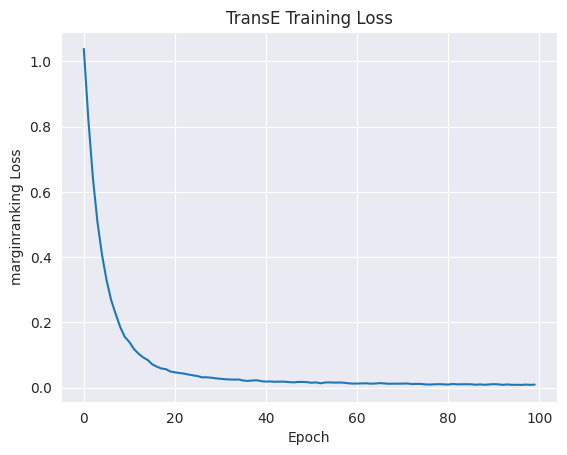

Metrics columns: ['Side', 'Rank_type', 'Metric', 'Value']

=== All TransE Evaluation Metrics ===
Side   Rank_type                              Metric        Value
head  optimistic                           hits_at_1 5.909091e-03
tail  optimistic                           hits_at_1 4.931818e-02
both  optimistic                           hits_at_1 2.761364e-02
head   realistic                           hits_at_1 5.909091e-03
tail   realistic                           hits_at_1 4.931818e-02
both   realistic                           hits_at_1 2.761364e-02
head pessimistic                           hits_at_1 5.909091e-03
tail pessimistic                           hits_at_1 4.931818e-02
both pessimistic                           hits_at_1 2.761364e-02
head  optimistic                           hits_at_3 1.159091e-02
tail  optimistic                           hits_at_3 9.227273e-02
both  optimistic                           hits_at_3 5.193182e-02
head   realistic                           hi

In [ ]:
result.plot_losses()
plt.title("TransE Training Loss")
plt.savefig("transe_loss.png", dpi=150)
plt.show()

metrics_df = result.metric_results.to_df()
metrics_df.to_csv("transe_metrics.csv", index=False)

# Show all columns so we know what we have
print("Metrics columns:", metrics_df.columns.tolist())
print()
print("=== All TransE Evaluation Metrics ===")
print(metrics_df.to_string(index=False))

In [ ]:
# Run this first to see what columns your metrics_df actually has
print(metrics_df.columns.tolist())
print(metrics_df.head(10))

['Side', 'Rank_type', 'Metric', 'Value']
   Side    Rank_type     Metric     Value
0  head   optimistic  hits_at_1  0.005909
1  tail   optimistic  hits_at_1  0.049318
2  both   optimistic  hits_at_1  0.027614
3  head    realistic  hits_at_1  0.005909
4  tail    realistic  hits_at_1  0.049318
5  both    realistic  hits_at_1  0.027614
6  head  pessimistic  hits_at_1  0.005909
7  tail  pessimistic  hits_at_1  0.049318
8  both  pessimistic  hits_at_1  0.027614
9  head   optimistic  hits_at_3  0.011591


### Extract and visualise the learned embeddings

After training, every entity has a 50-dimensional vector. I use PCA to compress 50D → 2D so I can plot and see whether students, courses, and skills cluster separately.

In [ ]:
model = result.model
entity_embeddings = model.entity_representations[0]().detach().cpu().numpy()
print("Entity embedding matrix shape:", entity_embeddings.shape)

entity_to_id   = tf.entity_to_id
id_to_entity   = {v: k for k, v in entity_to_id.items()}
relation_to_id = tf.relation_to_id
id_to_relation = {v: k for k, v in relation_to_id.items()}

print("Sample entities:", list(entity_to_id.keys())[:3])
print("Relations:", list(relation_to_id.keys()))

Entity embedding matrix shape: (13411, 50)
Sample entities: [' Accounting for Mergers and Acquisitions: Foundations', ' Advanced Topics in Derivative Pricing', ' Build, Train, and Deploy ML Pipelines using BERT']
Relations: ['enrolled_in', 'has_category', 'has_subcategory', 'teaches']


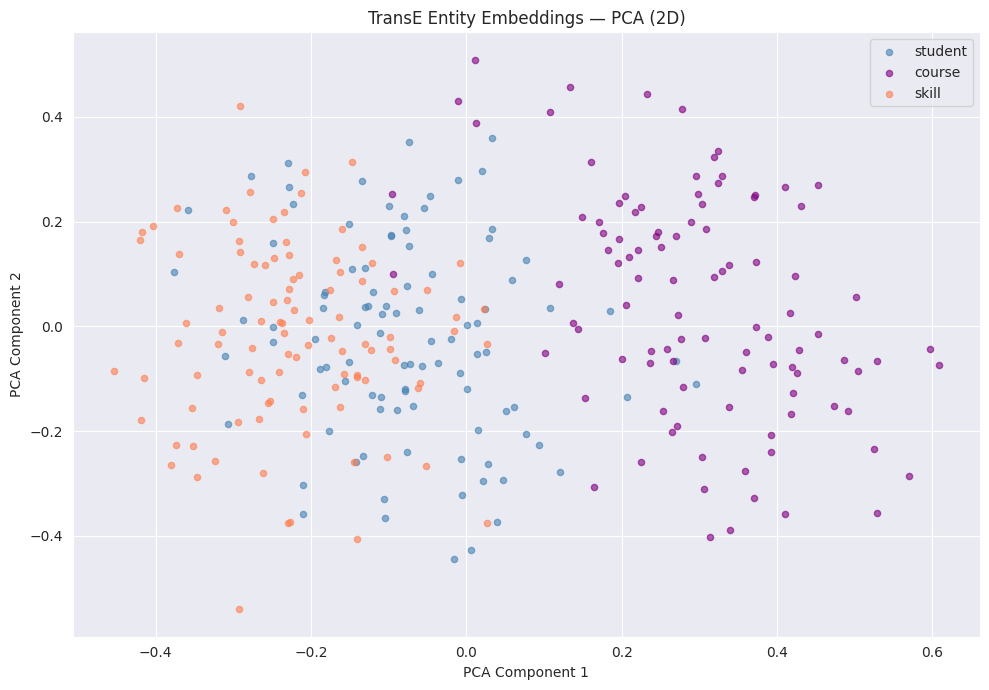

In [ ]:
student_ids_set = set(kg_df[kg_df['relation']=='enrolled_in']['head'].unique())
course_ids_set  = set(kg_df[kg_df['relation']=='has_category']['head'].unique())
skill_ids_set   = set(kg_df[kg_df['relation']=='teaches']['tail'].unique())

sample_size = 300
indices, labels = [], []
for name, eid in list(entity_to_id.items()):
    if   name in student_ids_set and labels.count('student') < sample_size//3:
        indices.append(eid); labels.append('student')
    elif name in course_ids_set  and labels.count('course')  < sample_size//3:
        indices.append(eid); labels.append('course')
    elif name in skill_ids_set   and labels.count('skill')   < sample_size//3:
        indices.append(eid); labels.append('skill')

reduced = PCA(n_components=2).fit_transform(entity_embeddings[indices])

colors = {'student': 'steelblue', 'course': 'purple', 'skill': 'coral'}
plt.figure(figsize=(10, 7))
for lbl in ['student', 'course', 'skill']:
    pts = reduced[[i for i, l in enumerate(labels) if l == lbl]]
    plt.scatter(pts[:,0], pts[:,1], c=colors[lbl], label=lbl, alpha=0.6, s=20)
plt.title("TransE Entity Embeddings — PCA (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.savefig("transe_embeddings_pca.png", dpi=150)
plt.show()


### Link prediction — course recommendation

For each student, TransE scores every possible `(student, enrolled_in, X)` triple.
The highest-scoring X values are the recommended courses.

**LOs covered:** LO8, LO11

In [ ]:
sample_student = kg_df[kg_df['relation']=='enrolled_in']['head'].iloc[0]
print("Recommending for student:", sample_student)

predictions = predict_target(
    model=model,
    head=sample_student,
    relation='enrolled_in',
    triples_factory=tf,
).df

# Filter to only show actual courses (remove student IDs and other entities)
course_set = set(kg_df[kg_df['relation']=='has_category']['head'].unique())
predictions_courses = predictions[predictions['tail_label'].isin(course_set)]

print("\nTop 10 recommended courses:")
print(predictions_courses.head(10)[['tail_label', 'score']].to_string(index=False))

Recommending for student: S1000

Top 10 recommended courses:
                                                       tail_label     score
           The Social and Technical Context of Health Informatics -6.469318
                                         Bioinformatic Methods II -6.585829
                   Managing Cybersecurity Incidents and Disasters -6.633575
   Advanced Leadership Skills for the 21st Century Specialization -6.717000
                                 Newborn Baby Care Specialization -6.722568
                            Introduction to Scrum Master Training -6.758693
          Energy Production, Distribution & Safety Specialization -6.782101
                              Excel Power Tools for Data Analysis -6.811015
                                  More C++ Programming and Unreal -6.827738
Foundations of Public Health Practice: The Public Health Approach -6.830059


In [ ]:
course_set = set(kg_df[kg_df['relation']=='has_category']['head'].unique())

print("=" * 65)
sample_students = kg_df[kg_df['relation']=='enrolled_in']['head'].iloc[:5].tolist()

for student in sample_students:
    current = kg_df[
        (kg_df['relation']=='enrolled_in') & (kg_df['head']==student)
    ]['tail'].values[0]

    preds = predict_target(
        model=model, head=student,
        relation='enrolled_in', triples_factory=tf,
    ).df

    # Filter to only actual courses — remove student IDs and other entities
    preds = preds[preds['tail_label'].isin(course_set)]

    # Remove the course they are already enrolled in
    top3 = preds[preds['tail_label'] != current].head(3)

    print(f"\nStudent : {student}")
    print(f"Enrolled: {current}")
    print("Recommended:")
    for _, row in top3.iterrows():
        print(f"  -> {row['tail_label']:<55}  score: {row['score']:.4f}")


Student : S1000
Enrolled: Food and Mood: Improving Mental Health Through Diet and Nutrition
Recommended:
  -> The Social and Technical Context of Health Informatics   score: -6.4693
  -> Bioinformatic Methods II                                 score: -6.5858
  -> Managing Cybersecurity Incidents and Disasters           score: -6.6336

Student : S1001
Enrolled: Antimicrobial Resistance in the Food Chain
Recommended:
  -> Market Research Specialization                           score: -6.0506
  -> A Complete Reinforcement Learning System (Capstone)      score: -6.1771
  -> Sampling People, Networks and Records                    score: -6.1814

Student : S1002
Enrolled: Exploratory Data Analysis for Machine Learning
Recommended:
  -> Game Design and Development 2: 2D Platformer             score: -6.2806
  -> Industrial Biotechnology                                 score: -6.3506
  -> Acupressure                                              score: -6.4386

Student : S1003
Enrolled: Coac

## Phase 3 — Graph Neural Network (GCN)

**What a GCN does:** Updates each node's features by aggregating its neighbours' features.
After 3 layers each node sees its 2-hop neighbourhood.

I initialise node features with TransE embeddings — this is the **hybrid** part.

**LOs covered:** LO3, LO6, LO12

In [ ]:
# Use ALL relation types — gives courses richer structure than students
all_entities  = pd.concat([kg_df['head'], kg_df['tail']]).unique()
entity_index  = {name: i for i, name in enumerate(all_entities)}
num_nodes_gcn = len(entity_index)
print("GCN graph nodes:", num_nodes_gcn)

srcs = [entity_index[h] for h in kg_df['head']]
tgts = [entity_index[t] for t in kg_df['tail']]
edge_index = torch.tensor([srcs + tgts, tgts + srcs], dtype=torch.long)
print("Edge index shape:", edge_index.shape)

enroll_df = kg_df[kg_df['relation'] == 'enrolled_in'].copy()

GCN graph nodes: 13411
Edge index shape: torch.Size([2, 44000])


In [ ]:
node_features = torch.zeros(num_nodes_gcn, 50)
for name, idx in entity_index.items():
    if name in tf.entity_to_id:
        transe_id = tf.entity_to_id[name]
        node_features[idx] = torch.tensor(entity_embeddings[transe_id])

print("Node feature matrix shape:", node_features.shape)

student_set = set(enroll_df['head'].unique())
labels_gcn  = torch.tensor(
    [1 if all_entities[i] in student_set else 0 for i in range(num_nodes_gcn)],
    dtype=torch.long
)

data = Data(x=node_features, edge_index=edge_index, y=labels_gcn)

perm = torch.randperm(num_nodes_gcn)
data.train_mask = torch.zeros(num_nodes_gcn, dtype=torch.bool)
data.test_mask  = torch.zeros(num_nodes_gcn, dtype=torch.bool)
data.train_mask[perm[:int(0.8 * num_nodes_gcn)]] = True
data.test_mask[ perm[int(0.8 * num_nodes_gcn):]] = True
print(data)

Node feature matrix shape: torch.Size([13411, 50])
Data(x=[13411, 50], edge_index=[2, 44000], y=[13411], train_mask=[13411], test_mask=[13411])


In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv3(x, edge_index)
        return F.log_softmax(x, dim=1)

gcn_model = GCN(input_dim=50, hidden_dim=128, output_dim=2)
optimizer  = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-4)
print(gcn_model)


GCN(
  (conv1): GCNConv(50, 128)
  (conv2): GCNConv(128, 128)
  (conv3): GCNConv(128, 2)
)


Epoch  40 | Loss: 0.4514
Epoch  80 | Loss: 0.3699
Epoch 120 | Loss: 0.3345
Epoch 160 | Loss: 0.3078
Epoch 200 | Loss: 0.2880
Epoch 240 | Loss: 0.2763
Epoch 280 | Loss: 0.2635
Epoch 320 | Loss: 0.2577
Epoch 360 | Loss: 0.2523
Epoch 400 | Loss: 0.2471
Epoch 440 | Loss: 0.2339
Epoch 480 | Loss: 0.2316
GCN training complete!


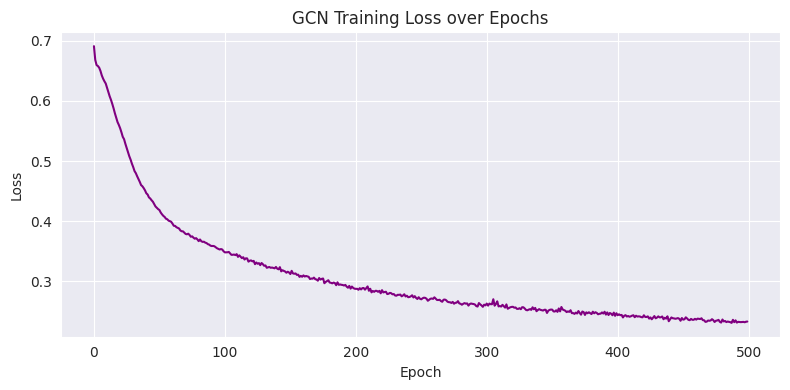

In [ ]:
gcn_model.train()
losses_gcn = []

for epoch in range(500):
    optimizer.zero_grad()
    out  = gcn_model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    losses_gcn.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {loss.item():.4f}')

print("GCN training complete!")

plt.figure(figsize=(8, 4))
plt.plot(losses_gcn, color='purple')
plt.title("GCN Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("gcn_training_loss.png", dpi=150)
plt.show()

## Phase 4 & 5 — Evaluate and Compare TransE vs GCN

**LOs covered:** LO1, LO3, LO4, LO8, LO11

In [ ]:
gcn_model.eval()
with torch.no_grad():
    out   = gcn_model(data)
    preds = out.argmax(dim=1)

y_true = data.y[data.test_mask].numpy()
y_pred = preds[data.test_mask].numpy()

gcn_accuracy = accuracy_score(y_true, y_pred)
print(f'GCN Test Accuracy: {gcn_accuracy:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['course', 'student']))

GCN Test Accuracy: 0.8278

              precision    recall  f1-score   support

      course       0.89      0.82      0.85      1663
     student       0.74      0.84      0.79      1020

    accuracy                           0.83      2683
   macro avg       0.82      0.83      0.82      2683
weighted avg       0.84      0.83      0.83      2683



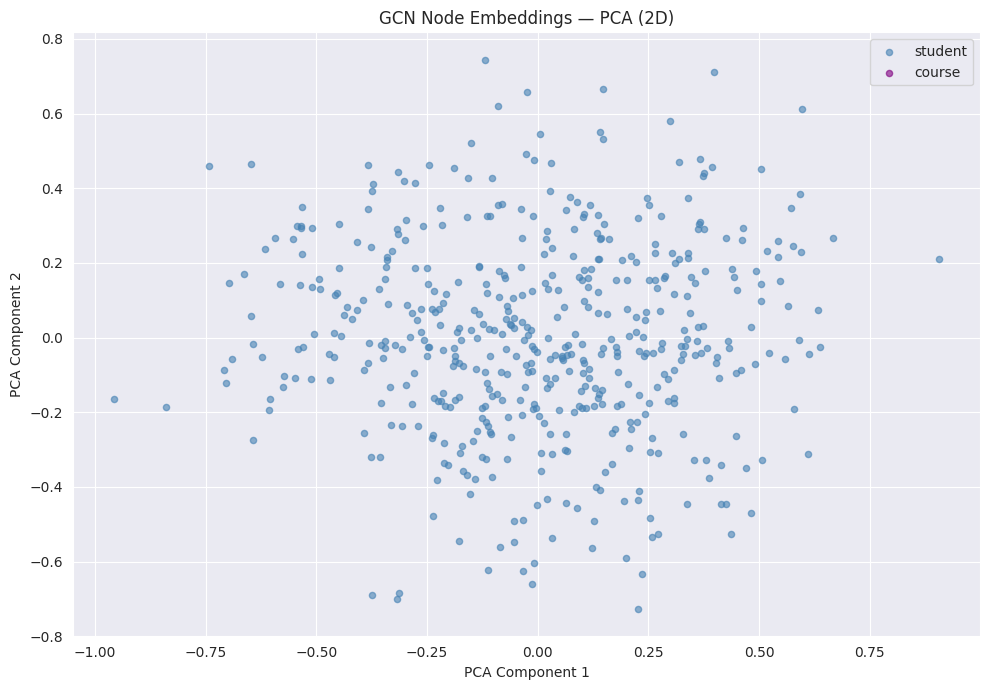

In [ ]:
gcn_model.eval()
with torch.no_grad():
    gcn_emb = gcn_model.conv1(data.x, data.edge_index).numpy()

gcn_reduced = PCA(n_components=2).fit_transform(gcn_emb[:500])
node_types  = ['student' if data.y[i]==1 else 'course' for i in range(500)]

plt.figure(figsize=(10, 7))
for lbl, clr in [('student','steelblue'), ('course','purple')]:
    pts = gcn_reduced[[i for i, t in enumerate(node_types) if t == lbl]]
    plt.scatter(pts[:,0], pts[:,1], c=clr, label=lbl, alpha=0.6, s=20)
plt.title("GCN Node Embeddings — PCA (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.savefig("gcn_embeddings_pca.png", dpi=150)
plt.show()

In [ ]:
print(metrics_df.columns.tolist())
print()
print(metrics_df.head(20).to_string())

['Side', 'Rank_type', 'Metric', 'Value']

    Side    Rank_type     Metric     Value
0   head   optimistic  hits_at_1  0.005909
1   tail   optimistic  hits_at_1  0.049318
2   both   optimistic  hits_at_1  0.027614
3   head    realistic  hits_at_1  0.005909
4   tail    realistic  hits_at_1  0.049318
5   both    realistic  hits_at_1  0.027614
6   head  pessimistic  hits_at_1  0.005909
7   tail  pessimistic  hits_at_1  0.049318
8   both  pessimistic  hits_at_1  0.027614
9   head   optimistic  hits_at_3  0.011591
10  tail   optimistic  hits_at_3  0.092273
11  both   optimistic  hits_at_3  0.051932
12  head    realistic  hits_at_3  0.011591
13  tail    realistic  hits_at_3  0.092273
14  both    realistic  hits_at_3  0.051932
15  head  pessimistic  hits_at_3  0.011591
16  tail  pessimistic  hits_at_3  0.092273
17  both  pessimistic  hits_at_3  0.051932
18  head   optimistic  hits_at_5  0.016818
19  tail   optimistic  hits_at_5  0.120227


In [ ]:
key = metrics_df[
    (metrics_df['Side'] == 'both') &
    (metrics_df['Rank_type'] == 'realistic') &
    (metrics_df['Metric'].isin([
        'hits_at_1', 'hits_at_3', 'hits_at_10',
        'inverse_harmonic_mean_rank'
    ]))
].set_index('Metric')['Value']

print("=" * 45)
print("       FINAL MODEL COMPARISON")
print("=" * 45)
print(f"TransE  MRR     : {key.get('inverse_harmonic_mean_rank', float('nan')):.4f}")
print(f"TransE  Hits@1  : {key.get('hits_at_1',  float('nan')):.4f}")
print(f"TransE  Hits@3  : {key.get('hits_at_3',  float('nan')):.4f}")
print(f"TransE  Hits@10 : {key.get('hits_at_10', float('nan')):.4f}")
print("-" * 45)
print(f"GCN     Accuracy: {gcn_accuracy:.4f}")
print("=" * 45)
print()
print("MRR     : mean reciprocal rank — how high correct course ranks (max 1.0)")
print("Hits@10 : correct course appears in top 10 predictions")
print("Accuracy: GCN correctly classifies student vs course nodes")

       FINAL MODEL COMPARISON
TransE  MRR     : 0.0525
TransE  Hits@1  : 0.0276
TransE  Hits@3  : 0.0519
TransE  Hits@10 : 0.0964
---------------------------------------------
GCN     Accuracy: 0.8278

MRR     : mean reciprocal rank — how high correct course ranks (max 1.0)
Hits@10 : correct course appears in top 10 predictions
Accuracy: GCN correctly classifies student vs course nodes
